# Gemini Models

## google-genai SDK

In [1]:
%pip install -q -U google-genai

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


In [32]:
import os
from google import genai
from dotenv import load_dotenv

In [33]:
load_dotenv()

True

In [2]:
gemini_api_key = os.getenv('GEMINI_API_KEY')

In [3]:
client = genai.Client(api_key=gemini_api_key)

In [5]:
response = client.models.generate_content(
    model='gemini-3-flash-preview',
    contents='What is GenAI?'
)

In [6]:
response

GenerateContentResponse(
  automatic_function_calling_history=[],
  candidates=[
    Candidate(
      content=Content(
        parts=[
          Part(
            text="""**GenAI**, or **Generative Artificial Intelligence**, is a branch of artificial intelligence capable of creating **new content** rather than just analyzing or acting on existing data.

While traditional AI is designed to recognize patterns, follow rules, and make predictions (like a Netflix recommendation or a spam filter), GenAI learns the underlying structure of data to generate entirely original outputs that resemble human-made work.

Here is a breakdown of how it works, what it can do, and why it matters:

---

### 1. How does it work?
GenAI is powered by **Large Language Models (LLMs)** and **Foundation Models**. These models are trained on massive datasets (billions of pages of text, images, or code).
*   **Pattern Recognition:** The AI doesn't "know" facts the way humans do; instead, it learns the statistical p

In [7]:
print(response.text)

**GenAI**, or **Generative Artificial Intelligence**, is a branch of artificial intelligence capable of creating **new content** rather than just analyzing or acting on existing data.

While traditional AI is designed to recognize patterns, follow rules, and make predictions (like a Netflix recommendation or a spam filter), GenAI learns the underlying structure of data to generate entirely original outputs that resemble human-made work.

Here is a breakdown of how it works, what it can do, and why it matters:

---

### 1. How does it work?
GenAI is powered by **Large Language Models (LLMs)** and **Foundation Models**. These models are trained on massive datasets (billions of pages of text, images, or code).
*   **Pattern Recognition:** The AI doesn't "know" facts the way humans do; instead, it learns the statistical probability of what comes next. For example, if you type "The cat sat on the...", the AI knows that "mat" is statistically more likely than "refrigerator."
*   **Neural Net

In [19]:
# help(client.models.generate_content)

## Gemini models using OpenAI SDK

In [9]:
from openai import OpenAI

In [10]:
client = OpenAI(api_key=gemini_api_key, base_url='https://generativelanguage.googleapis.com/v1beta/openai/')

In [11]:
client

In [15]:
response = client.chat.completions.create(
    model='gemini-2.5-flash',
    messages=[{'role': 'user', 'content': 'What is GenAI?'}]
)

In [18]:
print(response.choices[0].message.content)

**GenAI** stands for **Generative Artificial Intelligence**.

In essence, GenAI refers to a category of artificial intelligence models that are designed to **create new, original content** rather than just analyze or classify existing data.

Here's a breakdown of what that means:

1.  **Generative:** Unlike traditional AI that might identify a cat in an image (a discriminative task), a generative AI can *produce* a brand new image of a cat that has never existed before, based on its understanding of what a cat looks like.

2.  **How it Works (Simply):**
    *   **Training Data:** GenAI models are trained on vast amounts of existing data (text, images, audio, code, etc.). During this training, they learn the patterns, structures, styles, and relationships within that data.
    *   **Learning Patterns:** For example, a text-based GenAI learns grammar, syntax, common phrases, writing styles, and factual information. An image-based GenAI learns about shapes, colors, textures, objects, and 

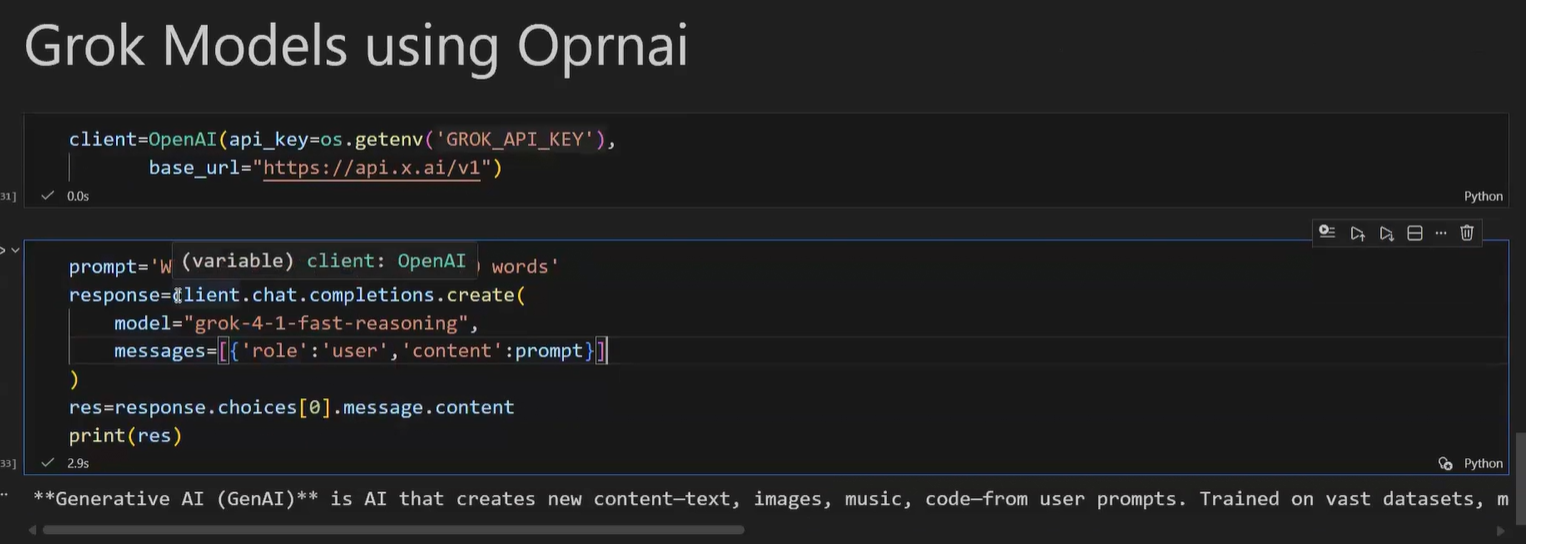

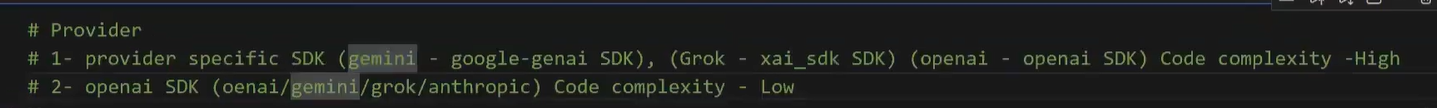

In [22]:
def create_client(provider, api_key):
    if provider == 'openai':
        client = OpenAI(api_key=api_key)
        print('OpenAI client is created..')
        return client
    elif provider == 'gemini':
        client = OpenAI(api_key=api_key, base_url='https://generativelanguage.googleapis.com/v1beta/openai/')
        print('Gemini client is created..')
        return client
    elif provider == 'grok':
        client = OpenAI(api_key=api_key, base_url='https://api.x.ai/v1')
        print('Grok client is created..')
        return client
    else:
        print("Invalid Provider....")
        return None

In [36]:
def get_llm_response(client, model, prompt):
    response = client.chat.completions.create(
        model=model,
        messages=[{'role': 'user', 'content': prompt}]
    )
    return response.choices[0].message.content

In [40]:
openai_key = os.getenv('OPENAI_SECRET_KEY')
gemini_key = os.getenv('GEMINI_API_KEY')
grok_key = os.getenv('GROK_API_KEY')

openai_model = 'gpt-4o-mini'
gemini_model = 'gemini-2.5-flash'
grok_model = 'grok-4'

provider = 'openai'

api_key = openai_key if provider == 'openai' else gemini_key if provider == 'gemini' else grok_key if provider == 'grok' else None
model = openai_model if provider == 'openai' else gemini_model if provider == 'gemini' else grok_model if provider == 'grok' else None

In [41]:
client = create_client(provider, api_key)
print(f'Model: {model}')

OpenAI client is created..
Model: gpt-4o-mini


In [42]:
res = get_llm_response(client, model, 'Who am I? Explain in one line.')
print(res)

You are a unique individual with your own thoughts, experiences, and identity.
